# CDM+CIM Memory Ablation Summary

Notebook này tổng hợp các run trong `results/cdm_cim_ablation` và ghi bảng/plot vào `_summary/`.

## 1. Setup

In [1]:
from __future__ import annotations

import json
import os
import re
import sys
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", str(Path("/tmp") / "matplotlib"))

import matplotlib
if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

try:
    display
except NameError:
    def display(value):
        print(value)

sns.set_theme(style="whitegrid", context="paper")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 220)


def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / ".git").exists() or ((candidate / "configs").exists() and (candidate / "scripts").exists()):
            return candidate
    return start


PROJECT_ROOT = find_project_root(Path.cwd())
SUMMARY_DIR = (PROJECT_ROOT / "results/cdm_cim_ablation").resolve()
OUT_DIR = SUMMARY_DIR / "_summary"
FIG_DIR = OUT_DIR / "figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

METRICS = ["WA", "UA", "WF1", "Macro-F1"]
PRIMARY_METRIC = "Macro-F1"
SSL_ORDER = ["wavlm", "hubert", "wav2vec"]
ABLATION_ORDER = ["full", "zero_dialogue_memory", "zero_interaction_memory", "shuffled_dialogue_memory", "shuffled_interaction_memory"]

print("PROJECT_ROOT =", PROJECT_ROOT)
print("SUMMARY_DIR  =", SUMMARY_DIR)
print("OUT_DIR      =", OUT_DIR)


PROJECT_ROOT = /home/jovyan/workspace/speech/conversational_ser
SUMMARY_DIR  = /home/jovyan/workspace/speech/conversational_ser/results/cdm_cim_ablation
OUT_DIR      = /home/jovyan/workspace/speech/conversational_ser/results/cdm_cim_ablation/_summary


## 2. Helpers

In [2]:
def read_json(path: Path) -> dict:
    return json.loads(path.read_text(encoding="utf-8"))


def pct(value) -> float:
    if pd.isna(value):
        return np.nan
    return 100.0 * float(value)


def mean_std_text(mean, std) -> str:
    if pd.isna(mean):
        return ""
    if pd.isna(std):
        return f"{pct(mean):.2f}"
    return f"{pct(mean):.2f} ± {pct(std):.2f}"


def relative_parts(path: Path) -> tuple[str, ...]:
    try:
        return path.relative_to(SUMMARY_DIR).parts
    except ValueError:
        return path.parts


TECHNICAL_SEGMENT_PATTERNS = (
    re.compile(r"^run_"),
    re.compile(r"^seed_"),
    re.compile(r"^test_Ses\d+$"),
)
TECHNICAL_SEGMENTS = {"cross_session", "phase_tests", "_summary", "cache"}


def clean_variant_parts(parts) -> list[str]:
    cleaned = []
    for part in parts:
        if part in TECHNICAL_SEGMENTS:
            continue
        if any(pattern.search(part) for pattern in TECHNICAL_SEGMENT_PATTERNS):
            continue
        if part.endswith(".json") or part.endswith(".csv") or part.endswith(".pth"):
            continue
        cleaned.append(part)
    return cleaned


def split_variant(variant: str) -> tuple[str, str]:
    parts = variant.split("/", 1)
    if len(parts) == 2:
        return parts[0], parts[1]
    return "", variant


def variant_from_cross_summary(path: Path) -> str:
    parts = list(relative_parts(path))
    stop_indices = [parts.index(token) for token in ["cross_session", "cross_session_summary.json"] if token in parts]
    end = min(stop_indices) if stop_indices else len(parts) - 1
    cleaned = clean_variant_parts(parts[:end])
    if cleaned:
        return "/".join(cleaned)
    return path.parent.name


def variant_from_metrics(path: Path) -> str:
    parts = list(relative_parts(path))
    stop_indices = [parts.index(token) for token in ["cross_session", "phase_tests", "metrics.json"] if token in parts]
    end = min(stop_indices) if stop_indices else len(parts) - 1
    cleaned = clean_variant_parts(parts[:end])
    if cleaned:
        return "/".join(cleaned)
    return path.parent.name


def run_id_from_path(path: Path) -> str:
    parts = relative_parts(path)
    for part in parts:
        if part.startswith("run_"):
            return part
    return "single_run"


def test_session_from_path(path: Path):
    match = re.search(r"test_Ses(\d+)", str(path))
    return int(match.group(1)) if match else np.nan


def flatten_metric_payload(payload: dict) -> dict:
    row = {}
    source = payload.get("test", payload)
    for metric in METRICS:
        value = source.get(metric, payload.get(metric))
        row[metric] = float(value) if value is not None else np.nan
    row["best_epoch"] = payload.get("best_epoch", payload.get("checkpoint_epoch", np.nan))
    return row


def ordered_variants(values) -> list[str]:
    present = set(str(value) for value in values)
    ordered = []
    for ssl in SSL_ORDER:
        for ablation in ABLATION_ORDER:
            variant = f"{ssl}/{ablation}"
            if variant in present:
                ordered.append(variant)
    ordered.extend(sorted(value for value in present if value not in ordered))
    return ordered


def dataframe_report(frame: pd.DataFrame) -> str:
    try:
        return frame.to_markdown(index=False)
    except ImportError:
        return "```\n" + frame.to_string(index=False) + "\n```"


## 3. Cross-Session Aggregate

In [3]:
cross_rows = []
fold_rows = []
missing_fold_rows = []
for path in sorted(SUMMARY_DIR.rglob("cross_session_summary.json")):
    if "_summary" in relative_parts(path):
        continue
    payload = read_json(path)
    variant = variant_from_cross_summary(path)
    ssl, ablation = split_variant(variant)
    run_id = payload.get("run_name") or run_id_from_path(path)
    expected_sessions = [int(session) for session in payload.get("test_sessions", [])]
    observed_sessions = [int(fold.get("test_session", test_session_from_path(Path(str(fold.get("output_dir", "")))) or -1)) for fold in payload.get("folds", [])]
    for missing_session in sorted(set(expected_sessions) - set(observed_sessions)):
        missing_fold_rows.append({
            "ssl": ssl,
            "ablation": ablation,
            "variant": variant,
            "run_id": run_id,
            "missing_test_session": missing_session,
            "summary_path": str(path.relative_to(PROJECT_ROOT)),
        })
    row = {
        "ssl": ssl,
        "ablation": ablation,
        "variant": variant,
        "run_id": run_id,
        "trainer_module": payload.get("trainer_module", ""),
        "summary_path": str(path.relative_to(PROJECT_ROOT)),
    }
    aggregate = payload.get("aggregate", {})
    for metric in METRICS:
        stats = aggregate.get(metric, {}) if isinstance(aggregate, dict) else {}
        row[f"{metric}_mean"] = float(stats.get("mean", np.nan))
        row[f"{metric}_std"] = float(stats.get("std", np.nan))
        row[f"{metric}_n"] = int(stats.get("n", 0)) if not pd.isna(stats.get("n", np.nan)) else 0
    cross_rows.append(row)

    for fold in payload.get("folds", []):
        metrics = fold.get("metrics", {})
        fold_row = {
            "ssl": ssl,
            "ablation": ablation,
            "variant": variant,
            "run_id": run_id,
            "test_session": int(fold.get("test_session", test_session_from_path(Path(str(fold.get("output_dir", "")))) or -1)),
            "output_dir": fold.get("output_dir", ""),
            "summary_path": str(path.relative_to(PROJECT_ROOT)),
        }
        for metric in METRICS:
            fold_row[metric] = float(metrics.get(metric, np.nan))
        fold_rows.append(fold_row)


for ssl in SSL_ORDER:
    full_root = PROJECT_ROOT / "results" / "main" / ssl / "cdm_cim" / "cross_session"
    full_paths = sorted(full_root.glob("*/cross_session_summary.json"), key=lambda item: item.stat().st_mtime if item.exists() else 0)
    if not full_paths:
        missing_fold_rows.append({
            "ssl": ssl,
            "ablation": "full",
            "variant": f"{ssl}/full",
            "run_id": "",
            "missing_test_session": "all",
            "summary_path": str(full_root.relative_to(PROJECT_ROOT)),
        })
        continue
    path = full_paths[-1]
    payload = read_json(path)
    variant = f"{ssl}/full"
    ablation = "full"
    run_id = payload.get("run_name") or run_id_from_path(path)
    row = {
        "ssl": ssl,
        "ablation": ablation,
        "variant": variant,
        "run_id": run_id,
        "trainer_module": payload.get("trainer_module", ""),
        "summary_path": str(path.relative_to(PROJECT_ROOT)),
    }
    aggregate = payload.get("aggregate", {})
    for metric in METRICS:
        stats = aggregate.get(metric, {}) if isinstance(aggregate, dict) else {}
        row[f"{metric}_mean"] = float(stats.get("mean", np.nan))
        row[f"{metric}_std"] = float(stats.get("std", np.nan))
        row[f"{metric}_n"] = int(stats.get("n", 0)) if not pd.isna(stats.get("n", np.nan)) else 0
    cross_rows.append(row)

    expected_sessions = [int(session) for session in payload.get("test_sessions", [])]
    observed_sessions = []
    for fold in payload.get("folds", []):
        test_session = int(fold.get("test_session", test_session_from_path(Path(str(fold.get("output_dir", "")))) or -1))
        observed_sessions.append(test_session)
        metrics = fold.get("metrics", {})
        fold_row = {
            "ssl": ssl,
            "ablation": ablation,
            "variant": variant,
            "run_id": run_id,
            "test_session": test_session,
            "output_dir": fold.get("output_dir", ""),
            "summary_path": str(path.relative_to(PROJECT_ROOT)),
        }
        for metric in METRICS:
            fold_row[metric] = float(metrics.get(metric, np.nan))
        fold_rows.append(fold_row)
    for missing_session in sorted(set(expected_sessions) - set(observed_sessions)):
        missing_fold_rows.append({
            "ssl": ssl,
            "ablation": ablation,
            "variant": variant,
            "run_id": run_id,
            "missing_test_session": missing_session,
            "summary_path": str(path.relative_to(PROJECT_ROOT)),
        })

aggregate_df = pd.DataFrame(cross_rows)
folds_df = pd.DataFrame(fold_rows)
missing_folds_df = pd.DataFrame(missing_fold_rows)

if not aggregate_df.empty:
    aggregate_df = aggregate_df.sort_values(f"{PRIMARY_METRIC}_mean", ascending=False).reset_index(drop=True)
    aggregate_df.to_csv(OUT_DIR / "cross_session_aggregate.csv", index=False)
if not folds_df.empty:
    folds_df = folds_df.sort_values(["ssl", "ablation", "run_id", "test_session"]).reset_index(drop=True)
    folds_df.to_csv(OUT_DIR / "cross_session_folds.csv", index=False)
if not missing_folds_df.empty:
    missing_folds_df = missing_folds_df.sort_values(["ssl", "ablation", "run_id", "missing_test_session"]).reset_index(drop=True)
missing_folds_df.to_csv(OUT_DIR / "missing_cross_session_folds.csv", index=False)

print(f"Found {len(aggregate_df)} cross-session summaries and {len(folds_df)} folds")
if missing_folds_df.empty:
    print("No missing folds reported by cross-session summaries.")
else:
    print(f"Missing {len(missing_folds_df)} expected fold(s); see missing_cross_session_folds.csv")
    display(missing_folds_df)
if aggregate_df.empty:
    print("No cross_session_summary.json files found under", SUMMARY_DIR)
else:
    display(aggregate_df)


Found 15 cross-session summaries and 75 folds
No missing folds reported by cross-session summaries.


,ssl,ablation,variant,run_id,trainer_module,summary_path,WA_mean,WA_std,WA_n,UA_mean,UA_std,UA_n,WF1_mean,WF1_std,WF1_n,Macro-F1_mean,Macro-F1_std,Macro-F1_n
0,wavlm,full,wavlm/full,run_20260704_063800,scripts.train_dual_branch,results/main/wavlm/cdm_cim/cross_session/run_2...,0.659768,0.035254,5,0.645520,0.029321,5,0.658524,0.036820,5,0.633521,0.031682,5
1,hubert,shuffled_dialogue_memory,hubert/shuffled_dialogue_memory,run_20260705_113110,scripts.train_dual_branch,results/cdm_cim_ablation/hubert/shuffled_dialo...,0.649667,0.037142,5,0.633528,0.024040,5,0.646402,0.034054,5,0.626211,0.023032,5
2,hubert,zero_interaction_memory,hubert/zero_interaction_memory,run_20260704_133110,scripts.train_dual_branch,results/cdm_cim_ablation/hubert/zero_interacti...,0.650503,0.040394,5,0.632144,0.032116,5,0.647876,0.040573,5,0.625468,0.030814,5
3,wavlm,shuffled_interaction_memory,wavlm/shuffled_interaction_memory,run_20260705_144916,scripts.train_dual_branch,results/cdm_cim_ablation/wavlm/shuffled_intera...,0.654570,0.041611,5,0.634661,0.045344,5,0.651719,0.040904,5,0.625408,0.043733,5
4,hubert,full,hubert/full,run_20260704_063742,scripts.train_dual_branch,results/main/hubert/cdm_cim/cross_session/run_...,0.646969,0.049689,5,0.637739,0.039786,5,0.644120,0.053114,5,0.624234,0.042008,5
5,hubert,shuffled_interaction_memory,hubert/shuffled_interaction_memory,run_20260705_144932,scripts.train_dual_branch,results/cdm_cim_ablation/hubert/shuffled_inter...,0.635467,0.053826,5,0.622977,0.033611,5,0.634962,0.052631,5,0.617162,0.034864,5
6,wavlm,zero_interaction_memory,wavlm/zero_interaction_memory,run_20260704_133214,scripts.train_dual_branch,results/cdm_cim_ablation/wavlm/zero_interactio...,0.643055,0.059712,5,0.630113,0.047798,5,0.640162,0.062782,5,0.615578,0.055236,5
7,wavlm,shuffled_dialogue_memory,wavlm/shuffled_dialogue_memory,run_20260705_113040,scripts.train_dual_branch,results/cdm_cim_ablation/wavlm/shuffled_dialog...,0.628120,0.056150,5,0.606584,0.050563,5,0.621990,0.052580,5,0.598285,0.048571,5
8,wav2vec,shuffled_dialogue_memory,wav2vec/shuffled_dialogue_memory,run_20260705_113135,scripts.train_dual_branch,results/cdm_cim_ablation/wav2vec/shuffled_dial...,0.562185,0.042774,5,0.539387,0.036635,5,0.548662,0.048252,5,0.528731,0.031486,5
9,wavlm,zero_dialogue_memory,wavlm/zero_dialogue_memory,run_20260704_113358,scripts.train_dual_branch,results/cdm_cim_ablation/wavlm/zero_dialogue_m...,0.561837,0.033339,5,0.524384,0.018040,5,0.538474,0.035925,5,0.511537,0.025263,5


## 4. Mean ± Std Table

In [4]:
if aggregate_df.empty:
    formatted_df = pd.DataFrame()
else:
    formatted_rows = []
    for _, row in aggregate_df.iterrows():
        item = {
            "ssl": row["ssl"],
            "ablation": row["ablation"],
            "variant": row["variant"],
            "run_id": row["run_id"],
            "trainer_module": row.get("trainer_module", ""),
        }
        for metric in METRICS:
            item[metric] = mean_std_text(row.get(f"{metric}_mean", np.nan), row.get(f"{metric}_std", np.nan))
        formatted_rows.append(item)
    formatted_df = pd.DataFrame(formatted_rows)
    formatted_df.to_csv(OUT_DIR / "cross_session_aggregate_formatted.csv", index=False)
    display(formatted_df)


,ssl,ablation,variant,run_id,trainer_module,WA,UA,WF1,Macro-F1
0,wavlm,full,wavlm/full,run_20260704_063800,scripts.train_dual_branch,65.98 ± 3.53,64.55 ± 2.93,65.85 ± 3.68,63.35 ± 3.17
1,hubert,shuffled_dialogue_memory,hubert/shuffled_dialogue_memory,run_20260705_113110,scripts.train_dual_branch,64.97 ± 3.71,63.35 ± 2.40,64.64 ± 3.41,62.62 ± 2.30
2,hubert,zero_interaction_memory,hubert/zero_interaction_memory,run_20260704_133110,scripts.train_dual_branch,65.05 ± 4.04,63.21 ± 3.21,64.79 ± 4.06,62.55 ± 3.08
3,wavlm,shuffled_interaction_memory,wavlm/shuffled_interaction_memory,run_20260705_144916,scripts.train_dual_branch,65.46 ± 4.16,63.47 ± 4.53,65.17 ± 4.09,62.54 ± 4.37
4,hubert,full,hubert/full,run_20260704_063742,scripts.train_dual_branch,64.70 ± 4.97,63.77 ± 3.98,64.41 ± 5.31,62.42 ± 4.20
5,hubert,shuffled_interaction_memory,hubert/shuffled_interaction_memory,run_20260705_144932,scripts.train_dual_branch,63.55 ± 5.38,62.30 ± 3.36,63.50 ± 5.26,61.72 ± 3.49
6,wavlm,zero_interaction_memory,wavlm/zero_interaction_memory,run_20260704_133214,scripts.train_dual_branch,64.31 ± 5.97,63.01 ± 4.78,64.02 ± 6.28,61.56 ± 5.52
7,wavlm,shuffled_dialogue_memory,wavlm/shuffled_dialogue_memory,run_20260705_113040,scripts.train_dual_branch,62.81 ± 5.61,60.66 ± 5.06,62.20 ± 5.26,59.83 ± 4.86
8,wav2vec,shuffled_dialogue_memory,wav2vec/shuffled_dialogue_memory,run_20260705_113135,scripts.train_dual_branch,56.22 ± 4.28,53.94 ± 3.66,54.87 ± 4.83,52.87 ± 3.15
9,wavlm,zero_dialogue_memory,wavlm/zero_dialogue_memory,run_20260704_113358,scripts.train_dual_branch,56.18 ± 3.33,52.44 ± 1.80,53.85 ± 3.59,51.15 ± 2.53


## 5. Mean Metrics Heatmap

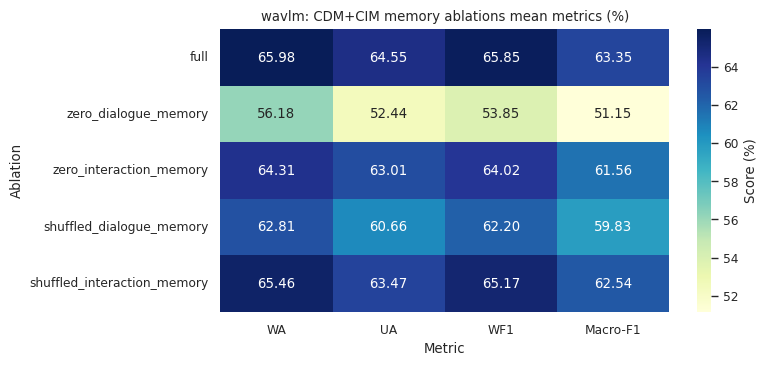

Saved /home/jovyan/workspace/speech/conversational_ser/results/cdm_cim_ablation/_summary/figures/wavlm_cross_session_mean_metrics_heatmap.png


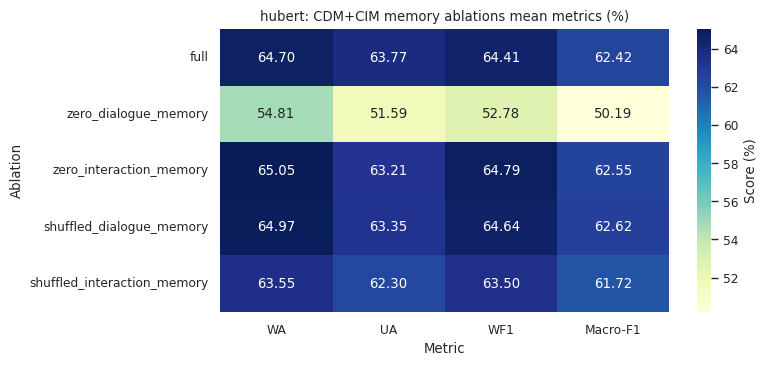

Saved /home/jovyan/workspace/speech/conversational_ser/results/cdm_cim_ablation/_summary/figures/hubert_cross_session_mean_metrics_heatmap.png


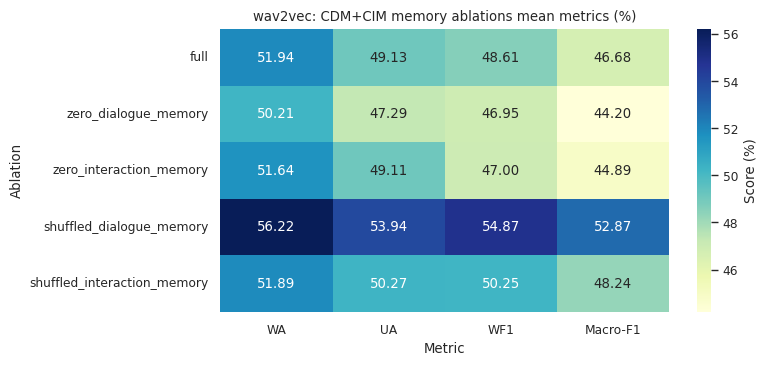

Saved /home/jovyan/workspace/speech/conversational_ser/results/cdm_cim_ablation/_summary/figures/wav2vec_cross_session_mean_metrics_heatmap.png


In [5]:
if aggregate_df.empty:
    print("No aggregate data for mean-metrics heatmap.")
else:
    metric_cols = [f"{metric}_mean" for metric in METRICS if f"{metric}_mean" in aggregate_df.columns]
    metric_order = [metric for metric in METRICS if f"{metric}_mean" in aggregate_df.columns]
    combined_frames = []

    for ssl in [item for item in SSL_ORDER if item in set(aggregate_df["ssl"])]:
        frame = aggregate_df[aggregate_df["ssl"].eq(ssl)].copy()
        mean_heat = frame.set_index("ablation")[metric_cols].rename(columns={f"{metric}_mean": metric for metric in METRICS}) * 100.0
        ordered_ablation = [ablation for ablation in ABLATION_ORDER if ablation in mean_heat.index]
        ordered_ablation.extend(sorted(ablation for ablation in mean_heat.index if ablation not in ordered_ablation))
        mean_heat = mean_heat.reindex(ordered_ablation)[metric_order]
        mean_heat.to_csv(OUT_DIR / f"{ssl}_cross_session_mean_metrics_heatmap.csv")
        combined_frames.append(mean_heat.assign(ssl=ssl).set_index("ssl", append=True).reorder_levels(["ssl", "ablation"]))

        plt.figure(figsize=(max(7, 1.0 * mean_heat.shape[1] + 4), max(3.2, 0.45 * len(mean_heat) + 1.5)))
        sns.heatmap(mean_heat, annot=True, fmt=".2f", cmap="YlGnBu", cbar_kws={"label": "Score (%)"})
        plt.title(f"{ssl}: CDM+CIM memory ablations mean metrics (%)")
        plt.xlabel("Metric")
        plt.ylabel("Ablation")
        plt.tight_layout()
        fig_path = FIG_DIR / f"{ssl}_cross_session_mean_metrics_heatmap.png"
        plt.savefig(fig_path, dpi=180, bbox_inches="tight")
        plt.show()
        print("Saved", fig_path)

    if combined_frames:
        combined_heat = pd.concat(combined_frames).sort_index(level=[0, 1])
        combined_heat.to_csv(OUT_DIR / "cross_session_mean_metrics_heatmap.csv")
    else:
        print("No SSL groups found for mean-metrics heatmap.")


## 6. Held-Out Session Heatmap

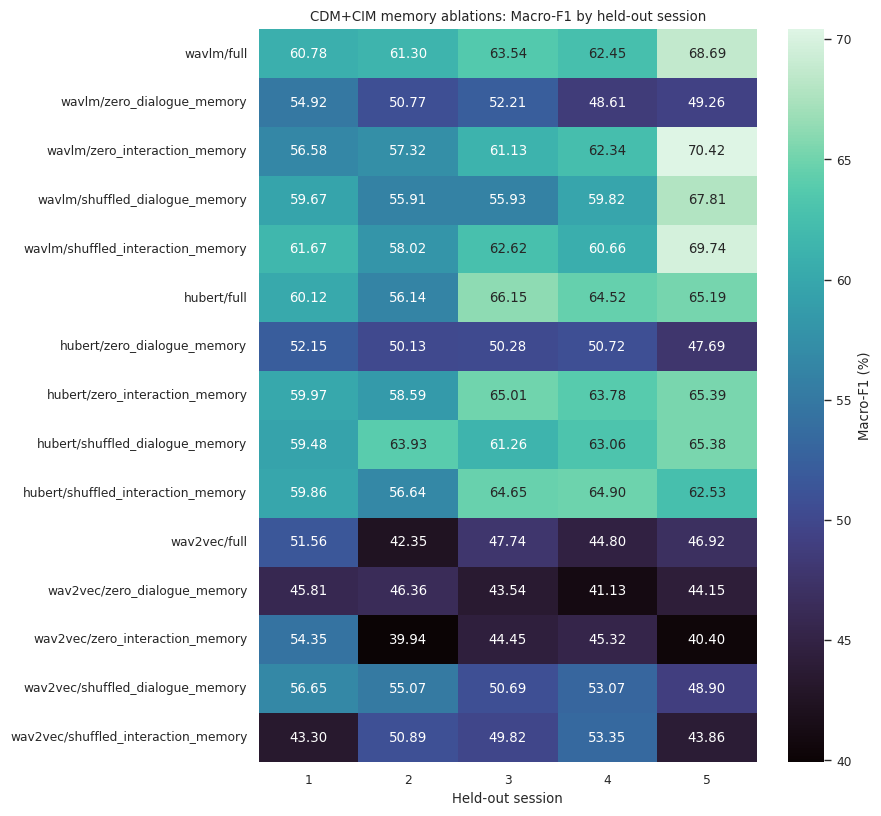

Saved /home/jovyan/workspace/speech/conversational_ser/results/cdm_cim_ablation/_summary/figures/cross_session_heatmap.png


In [6]:
if folds_df.empty:
    print("No fold-level data for heatmap.")
else:
    pivot = folds_df.pivot_table(
        index="variant",
        columns="test_session",
        values=PRIMARY_METRIC,
        aggfunc="max",
    )
    pivot = pivot.reindex(ordered_variants(set(aggregate_df["variant"].drop_duplicates().tolist()) | set(pivot.index.tolist())))
    pivot.to_csv(OUT_DIR / f"cross_session_{PRIMARY_METRIC.lower().replace('-', '_')}_by_session.csv")
    plt.figure(figsize=(max(7, 1.0 * pivot.shape[1] + 4), max(3.5, 0.45 * len(pivot) + 1.5)))
    sns.heatmap(pivot * 100.0, annot=True, fmt=".2f", cmap="mako", cbar_kws={"label": f"{PRIMARY_METRIC} (%)"})
    plt.title(f"CDM+CIM memory ablations: {PRIMARY_METRIC} by held-out session")
    plt.xlabel("Held-out session")
    plt.ylabel("")
    plt.tight_layout()
    fig_path = FIG_DIR / "cross_session_heatmap.png"
    plt.savefig(fig_path, dpi=180, bbox_inches="tight")
    plt.show()
    print("Saved", fig_path)


## 7. SSL x Ablation Matrix

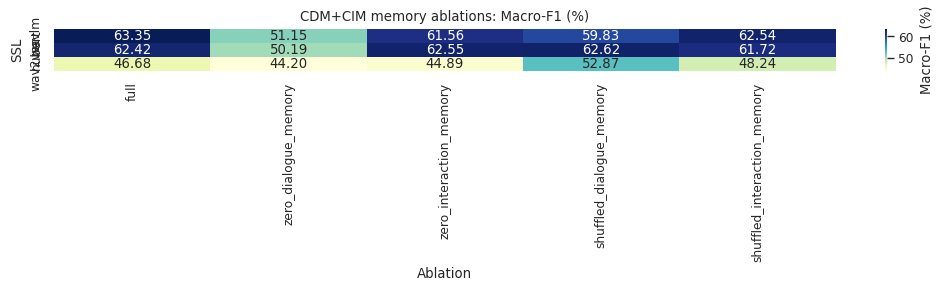

Saved /home/jovyan/workspace/speech/conversational_ser/results/cdm_cim_ablation/_summary/figures/ssl_ablation_macro_f1_matrix.png


In [7]:
if aggregate_df.empty:
    print("No aggregate data for SSL x ablation matrix.")
else:
    matrix = aggregate_df.pivot_table(index="ssl", columns="ablation", values=f"{PRIMARY_METRIC}_mean", aggfunc="max") * 100.0
    matrix = matrix.reindex([ssl for ssl in SSL_ORDER if ssl in matrix.index])
    matrix = matrix.reindex(columns=[ablation for ablation in ABLATION_ORDER if ablation in matrix.columns])
    matrix.to_csv(OUT_DIR / f"ssl_ablation_{PRIMARY_METRIC.lower().replace('-', '_')}_matrix.csv")
    plt.figure(figsize=(max(6, 1.5 * len(matrix.columns) + 3), max(3, 0.5 * len(matrix) + 1.5)))
    sns.heatmap(matrix, annot=True, fmt=".2f", cmap="YlGnBu", cbar_kws={"label": f"{PRIMARY_METRIC} (%)"})
    plt.title(f"CDM+CIM memory ablations: {PRIMARY_METRIC} (%)")
    plt.xlabel("Ablation")
    plt.ylabel("SSL")
    plt.tight_layout()
    fig_path = FIG_DIR / f"ssl_ablation_{PRIMARY_METRIC.lower().replace('-', '_')}_matrix.png"
    plt.savefig(fig_path, dpi=180, bbox_inches="tight")
    plt.show()
    print("Saved", fig_path)


## 8. Full Minus Ablation Delta

,ssl,ablation,full_WA,ablation_WA,delta_WA,full_UA,ablation_UA,delta_UA,full_WF1,ablation_WF1,delta_WF1,full_Macro-F1,ablation_Macro-F1,delta_Macro-F1
0,wavlm,zero_dialogue_memory,65.976775,56.183700,9.793075,64.551970,52.438372,12.113598,65.852432,53.847383,12.005048,63.352139,51.153651,12.198488
1,wavlm,zero_interaction_memory,65.976775,64.305528,1.671247,64.551970,63.011265,1.540706,65.852432,64.016155,1.836276,63.352139,61.557824,1.794315
2,wavlm,shuffled_dialogue_memory,65.976775,62.812041,3.164734,64.551970,60.658397,3.893574,65.852432,62.198983,3.653449,63.352139,59.828504,3.523635
3,wavlm,shuffled_interaction_memory,65.976775,65.457024,0.519751,64.551970,63.466136,1.085834,65.852432,65.171862,0.680569,63.352139,62.540816,0.811323
4,hubert,zero_dialogue_memory,64.696929,54.809752,9.887176,63.773885,51.591940,12.181945,64.411993,52.784511,11.627482,62.423387,50.193609,12.229778
5,hubert,zero_interaction_memory,64.696929,65.050312,-0.353383,63.773885,63.214417,0.559468,64.411993,64.787599,-0.375606,62.423387,62.546766,-0.123379
6,hubert,shuffled_dialogue_memory,64.696929,64.966721,-0.269792,63.773885,63.352800,0.421085,64.411993,64.640216,-0.228222,62.423387,62.621078,-0.197691
7,hubert,shuffled_interaction_memory,64.696929,63.546650,1.150279,63.773885,62.297717,1.476168,64.411993,63.496175,0.915819,62.423387,61.716155,0.707232
8,wav2vec,zero_dialogue_memory,51.943090,50.210620,1.732470,49.127061,47.289918,1.837143,48.611580,46.954803,1.656777,46.675159,44.197984,2.477175
9,wav2vec,zero_interaction_memory,51.943090,51.639469,0.303621,49.127061,49.108919,0.018142,48.611580,46.995332,1.616247,46.675159,44.890353,1.784806


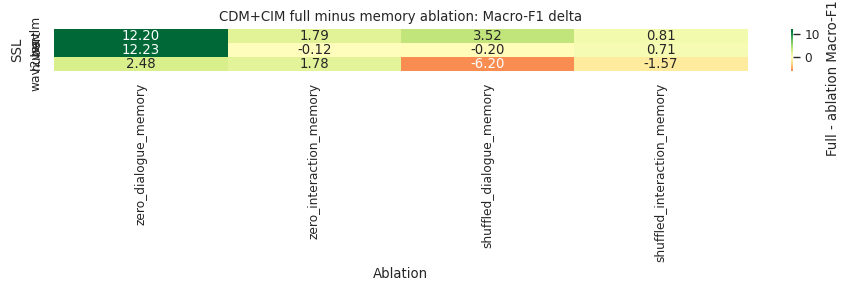

Saved /home/jovyan/workspace/speech/conversational_ser/results/cdm_cim_ablation/_summary/figures/full_minus_ablation_macro_f1_matrix.png


In [8]:
if aggregate_df.empty:
    print("No aggregate data for full-minus-ablation delta.")
else:
    delta_rows = []
    for ssl in SSL_ORDER:
        full_row = aggregate_df[(aggregate_df["ssl"].eq(ssl)) & (aggregate_df["ablation"].eq("full"))]
        if full_row.empty:
            continue
        full_row = full_row.iloc[0]
        for ablation in [item for item in ABLATION_ORDER if item != "full"]:
            ablation_row = aggregate_df[(aggregate_df["ssl"].eq(ssl)) & (aggregate_df["ablation"].eq(ablation))]
            if ablation_row.empty:
                continue
            ablation_row = ablation_row.iloc[0]
            item = {"ssl": ssl, "ablation": ablation}
            for metric in METRICS:
                item[f"full_{metric}"] = pct(full_row[f"{metric}_mean"])
                item[f"ablation_{metric}"] = pct(ablation_row[f"{metric}_mean"])
                item[f"delta_{metric}"] = pct(full_row[f"{metric}_mean"] - ablation_row[f"{metric}_mean"])
            delta_rows.append(item)
    full_delta_df = pd.DataFrame(delta_rows)
    full_delta_df.to_csv(OUT_DIR / "full_minus_ablation_delta.csv", index=False)
    if full_delta_df.empty:
        print("No paired full/ablation rows found.")
    else:
        display(full_delta_df)

        compact = pd.DataFrame(index=[ssl for ssl in SSL_ORDER if ssl in set(full_delta_df["ssl"])])
        for ablation in [item for item in ABLATION_ORDER if item != "full"]:
            values = full_delta_df[full_delta_df["ablation"].eq(ablation)].set_index("ssl")[f"delta_{PRIMARY_METRIC}"]
            compact[ablation] = values
        compact.to_csv(OUT_DIR / f"full_minus_ablation_{PRIMARY_METRIC.lower().replace('-', '_')}_matrix.csv")
        plt.figure(figsize=(max(6, 1.6 * len(compact.columns) + 3), max(3, 0.5 * len(compact) + 1.5)))
        sns.heatmap(compact, annot=True, fmt=".2f", cmap="RdYlGn", center=0, cbar_kws={"label": f"Full - ablation {PRIMARY_METRIC} (points)"})
        plt.title(f"CDM+CIM full minus memory ablation: {PRIMARY_METRIC} delta")
        plt.xlabel("Ablation")
        plt.ylabel("SSL")
        plt.tight_layout()
        fig_path = FIG_DIR / f"full_minus_ablation_{PRIMARY_METRIC.lower().replace('-', '_')}_matrix.png"
        plt.savefig(fig_path, dpi=180, bbox_inches="tight")
        plt.show()
        print("Saved", fig_path)


## 8. Standalone Metrics

In [9]:
single_rows = []
for path in sorted(SUMMARY_DIR.rglob("metrics.json")):
    parts = set(relative_parts(path))
    if "_summary" in parts or "phase_tests" in parts or "cross_session" in parts:
        continue
    payload = read_json(path)
    variant = variant_from_metrics(path)
    ssl, ablation = split_variant(variant)
    row = {
        "ssl": ssl,
        "ablation": ablation,
        "variant": variant,
        "run_id": run_id_from_path(path),
        "metrics_path": str(path.relative_to(PROJECT_ROOT)),
    }
    row.update(flatten_metric_payload(payload))
    single_rows.append(row)

single_metrics_df = pd.DataFrame(single_rows)
if not single_metrics_df.empty:
    single_metrics_df = single_metrics_df.sort_values(PRIMARY_METRIC, ascending=False).reset_index(drop=True)
    single_metrics_df.to_csv(OUT_DIR / "single_run_metrics.csv", index=False)
    display(single_metrics_df)
else:
    print("No standalone metrics.json files found outside cross_session folds.")


No standalone metrics.json files found outside cross_session folds.


## 9. Report

In [10]:
report = [
    f"# CDM+CIM Memory Ablation Summary: `{SUMMARY_DIR.relative_to(PROJECT_ROOT)}`",
    "",
    f"- Cross-session summaries: {len(aggregate_df)}",
    f"- Cross-session folds: {len(folds_df)}",
    f"- Standalone metric files: {len(single_metrics_df)}",
    "",
]
if not formatted_df.empty:
    report.extend(["## Cross-Session Aggregate", "", dataframe_report(formatted_df), ""])
if not missing_folds_df.empty:
    report.extend(["## Missing Cross-Session Folds", "", dataframe_report(missing_folds_df), ""])
if not single_metrics_df.empty:
    report.extend(["## Standalone Metrics", "", dataframe_report(single_metrics_df), ""])

report_path = OUT_DIR / "summary.md"
report_path.write_text("\n".join(report) + "\n", encoding="utf-8")
print("Saved", report_path)


Saved /home/jovyan/workspace/speech/conversational_ser/results/cdm_cim_ablation/_summary/summary.md


## 10. Saved Outputs

In [11]:
outputs = sorted(p.relative_to(OUT_DIR) for p in OUT_DIR.rglob("*") if p.is_file())
print(f"Saved {len(outputs)} files under {OUT_DIR}")
for path in outputs:
    print(path)


Saved 20 files under /home/jovyan/workspace/speech/conversational_ser/results/cdm_cim_ablation/_summary
cross_session_aggregate.csv
cross_session_aggregate_formatted.csv
cross_session_folds.csv
cross_session_macro_f1_by_session.csv
cross_session_mean_metrics_heatmap.csv
figures/cross_session_heatmap.png
figures/cross_session_mean_metrics_heatmap.png
figures/full_minus_ablation_macro_f1_matrix.png
figures/hubert_cross_session_mean_metrics_heatmap.png
figures/ssl_ablation_macro_f1_matrix.png
figures/wav2vec_cross_session_mean_metrics_heatmap.png
figures/wavlm_cross_session_mean_metrics_heatmap.png
full_minus_ablation_delta.csv
full_minus_ablation_macro_f1_matrix.csv
hubert_cross_session_mean_metrics_heatmap.csv
missing_cross_session_folds.csv
ssl_ablation_macro_f1_matrix.csv
summary.md
wav2vec_cross_session_mean_metrics_heatmap.csv
wavlm_cross_session_mean_metrics_heatmap.csv
